# 🚀 Near-Earth Object (NEO) Hazard Prediction System
## Sprint 4: Deployment & MLOps
**Goal:** Make the model usable in real-world applications

---
| Sprint | Focus Area | Status |
|--------|------------|--------|
| Sprint 1 | Data Understanding & Preprocessing | ✅ Done |
| Sprint 2 | Model Building & Evaluation | ✅ Done |
| Sprint 3 | Optimization & Final Model | ✅ Done |
| **Sprint 4** | **Deployment & MLOps** | ✅ Current |

## Step 1: Import Libraries & Rebuild Final Model Pipeline

In [28]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import joblib
import os
import json
import datetime
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Load Data & Reproduce Sprint 3 Results

In [29]:
# Load cleaned dataset from Sprint 1 output
df = pd.read_csv('sprint1.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 90829 rows × 6 columns


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1
2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1


In [30]:
# ── Feature Engineering (from Sprint 3) ──────────────────────────────
df['Avg_diameter']           = (df['est_diameter_min'] + df['est_diameter_max']) / 2
df['Diameter_range']         = df['est_diameter_max'] - df['est_diameter_min']
df['Velocity_distance_ratio']= df['relative_velocity'] / df['miss_distance']

print('✅ Engineered features added:')
print('   • Avg_diameter            — mean of min/max diameter')
print('   • Diameter_range          — spread of diameter measurement')
print('   • Velocity_distance_ratio — threat intensity proxy')

# Separate features and target
X_raw = df.drop('hazardous', axis=1)
y     = df['hazardous']

print(f'\nFeature matrix: {X_raw.shape} | Target: {y.shape}')

✅ Engineered features added:
   • Avg_diameter            — mean of min/max diameter
   • Diameter_range          — spread of diameter measurement
   • Velocity_distance_ratio — threat intensity proxy

Feature matrix: (90829, 8) | Target: (90829,)


In [31]:
# ── Drop highly correlated features (from Sprint 3) ──────────────────
corr_matrix = X_raw.corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop     = [col for col in upper.columns if any(upper[col] > 0.90)]

print(f'Columns dropped (corr > 0.90): {to_drop}')
X = X_raw.drop(columns=to_drop)
print(f'Final feature set: {X.columns.tolist()}')

Columns dropped (corr > 0.90): ['est_diameter_max', 'absolute_magnitude', 'Avg_diameter', 'Diameter_range']
Final feature set: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'Velocity_distance_ratio']


In [32]:
# ── Train-Test Split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# ── Scaling ──────────────────────────────────────────────────────────
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled  = scaler.transform(X_test)

# ── RFE Feature Selection ─────────────────────────────────────────────
rf_for_rfe = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf_for_rfe, n_features_to_select=5)
rfe.fit(x_train_scaled, y_train)

selected_features   = X.columns[rfe.support_]
x_train_selected    = rfe.transform(x_train_scaled)
x_test_selected     = rfe.transform(x_test_scaled)

print(f'\n✅ Selected features via RFE: {selected_features.tolist()}')

Train: (72663, 4) | Test: (18166, 4)

✅ Selected features via RFE: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'Velocity_distance_ratio']


In [33]:
# ── Final Model — Best Hyperparameters from Sprint 3 GridSearchCV ────
# Best params found in Sprint 3 (reproduce here):
best_params = {
    'n_estimators'    : 200,
    'max_depth'       : 10,
    'min_samples_split': 2,
    'min_samples_leaf' : 1,
    'random_state'    : 42,
    'class_weight': {0: 1, 1: 3}
}

final_model = RandomForestClassifier(**best_params)
final_model.fit(x_train_selected, y_train)

y_pred    = final_model.predict(x_test_selected)
y_prob    = final_model.predict_proba(x_test_selected)[:, 1]

print('✅ Final model trained with best hyperparameters!')
print(f'   Params: {best_params}')

✅ Final model trained with best hyperparameters!
   Params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'class_weight': {0: 1, 1: 3}}


In [34]:
# ── Final Evaluation Report ───────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('\n' + '='*50)
print('     FINAL MODEL EVALUATION REPORT')
print('='*50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('='*50)
print(classification_report(y_test, y_pred, target_names=['Non-Hazardous', 'Hazardous']))


     FINAL MODEL EVALUATION REPORT
  Accuracy  : 0.8468
  Precision : 0.3636
  Recall    : 0.7663
  F1 Score  : 0.4932
  ROC-AUC   : 0.9178
               precision    recall  f1-score   support

Non-Hazardous       0.97      0.86      0.91     16399
    Hazardous       0.36      0.77      0.49      1767

     accuracy                           0.85     18166
    macro avg       0.67      0.81      0.70     18166
 weighted avg       0.91      0.85      0.87     18166



## Step 3: Build ML Pipeline (Preprocessing + Model)

In [35]:
# Build a single sklearn Pipeline that chains Scaler → Model
# Note: RFE pre-selected 5 features — we train the pipeline on those directly

ml_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(**best_params))
])

# Prepare data using the selected feature names for the pipeline
X_train_sel_df = pd.DataFrame(x_train_selected, columns=selected_features)
X_test_sel_df  = pd.DataFrame(x_test_selected,  columns=selected_features)

ml_pipeline.fit(X_train_sel_df, y_train)

pipeline_pred = ml_pipeline.predict(X_test_sel_df)
pipeline_acc  = accuracy_score(y_test, pipeline_pred)

print('✅ ML Pipeline built successfully!')
print(f'   Pipeline steps   : {[s[0] for s in ml_pipeline.steps]}')
print(f'   Pipeline Accuracy: {pipeline_acc:.4f}')
ml_pipeline

✅ ML Pipeline built successfully!
   Pipeline steps   : ['scaler', 'model']
   Pipeline Accuracy: 0.8468


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


## Step 4: Model Serialization — Save Model & Artifacts

In [36]:
# Create models/ directory
os.makedirs('models', exist_ok=True)

# 1. Save the full pipeline (.pkl)
with open('models/neo_pipeline.pkl', 'wb') as f:
    pickle.dump(ml_pipeline, f)

# 2. Save with joblib (.joblib) — preferred for sklearn
joblib.dump(ml_pipeline, 'models/neo_pipeline.joblib')

# 3. Save the scaler separately (for inference scripts)
joblib.dump(scaler, 'models/scaler.joblib')

# 4. Save the RFE selector
joblib.dump(rfe, 'models/rfe_selector.joblib')

# 5. Save selected feature names
with open('models/selected_features.json', 'w') as f:
    json.dump(selected_features.tolist(), f)

# 6. Save model metadata
metadata = {
    'model_name'      : 'RandomForestClassifier',
    'version'         : '1.0.0',
    'trained_on'      : str(datetime.date.today()),
    'features'        : selected_features.tolist(),
    'hyperparameters' : best_params,
    'metrics': {
        'accuracy' : round(acc, 4),
        'precision': round(prec, 4),
        'recall'   : round(rec, 4),
        'f1_score' : round(f1, 4),
        'roc_auc'  : round(auc, 4)
    }
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('✅ Model artifacts saved to models/ directory:')
for fname in os.listdir('models'):
    size = os.path.getsize(f'models/{fname}')
    print(f'   📦 {fname}  ({size:,} bytes)')

✅ Model artifacts saved to models/ directory:
   📦 experiment_log.json  (1,459 bytes)
   📦 model_metadata.json  (684 bytes)
   📦 neo_pipeline.joblib  (8,570,450 bytes)
   📦 neo_pipeline.pkl  (8,552,608 bytes)
   📦 prediction_log.csv  (358 bytes)
   📦 rfe_selector.joblib  (71,083,888 bytes)
   📦 scaler.joblib  (1,015 bytes)
   📦 selected_features.json  (85 bytes)


## Step 5: Load & Verify Saved Model

In [37]:
# Load the saved pipeline and verify it works
loaded_pipeline = joblib.load('models/neo_pipeline.joblib')

# Load selected features
with open('models/selected_features.json') as f:
    loaded_features = json.load(f)

# Verify predictions match
loaded_pred = loaded_pipeline.predict(X_test_sel_df)
loaded_acc  = accuracy_score(y_test, loaded_pred)

print('✅ Model loaded and verified!')
print(f'   Loaded features : {loaded_features}')
print(f'   Loaded accuracy : {loaded_acc:.4f}')
print(f'   Predictions match original: {np.array_equal(y_pred, loaded_pred)}')

✅ Model loaded and verified!
   Loaded features : ['est_diameter_min', 'relative_velocity', 'miss_distance', 'Velocity_distance_ratio']
   Loaded accuracy : 0.8468
   Predictions match original: True


## Step 6: Prediction Function — Inference on New Data

In [38]:
def predict_hazard(input_dict: dict) -> dict:
    # Load artifacts
    pipeline_loaded = joblib.load('models/neo_pipeline.joblib')
    rfe_loaded      = joblib.load('models/rfe_selector.joblib')
    scaler_loaded   = joblib.load('models/scaler.joblib')

    with open('models/selected_features.json') as f:
        sel_features = json.load(f)

    # Step 1: Build raw DataFrame
    row = pd.DataFrame([input_dict])

    # Step 2: Feature engineering (same as training)
    row['Avg_diameter']            = (row['est_diameter_min'] + row['est_diameter_max']) / 2
    row['Diameter_range']          = row['est_diameter_max'] - row['est_diameter_min']
    row['Velocity_distance_ratio'] = row['relative_velocity'] / row['miss_distance']

    # Step 3: Match EXACT columns & order the scaler was fit on
    # (scaler was fit on X after corr-drop but BEFORE est_diameter_min/max were removed)
    scaler_cols = scaler_loaded.feature_names_in_.tolist()
    row_clean   = row[scaler_cols]   # reorder/select to match fit-time columns exactly

    # Step 4: Scale → RFE select → predict
    row_scaled   = scaler_loaded.transform(row_clean)
    row_selected = rfe_loaded.transform(row_scaled)
    row_df       = pd.DataFrame(row_selected, columns=sel_features)

    prediction  = pipeline_loaded.predict(row_df)[0]
    probability = pipeline_loaded.predict_proba(row_df)[0][1]

    risk = 'HIGH RISK ⚠️' if prediction == 1 else 'SAFE ✅'
    return {
        'prediction' : int(prediction),
        'probability': round(float(probability), 4),
        'risk_label' : risk
    }

In [39]:
# ── Test the prediction function with a sample asteroid ───────────────
sample_asteroid = {
    'est_diameter_min' : 0.25,
    'est_diameter_max' : 0.56,
    'relative_velocity': 75000.0,
    'miss_distance'    : 35000000.0,
    'absolute_magnitude': 20.5
}

result = predict_hazard(sample_asteroid)

print('🔭 Sample Asteroid Input:')
for k, v in sample_asteroid.items():
    print(f'   {k}: {v}')
print(f'\n🎯 Prediction Result:')
print(f'   Class       : {result["prediction"]} ({"Hazardous" if result["prediction"]==1 else "Non-Hazardous"})')
print(f'   Probability : {result["probability"]*100:.2f}%')
print(f'   Risk Label  : {result["risk_label"]}')

🔭 Sample Asteroid Input:
   est_diameter_min: 0.25
   est_diameter_max: 0.56
   relative_velocity: 75000.0
   miss_distance: 35000000.0
   absolute_magnitude: 20.5

🎯 Prediction Result:
   Class       : 1 (Hazardous)
   Probability : 53.68%
   Risk Label  : HIGH RISK ⚠️


## Step 7: ROC Curve & Final Visualizations

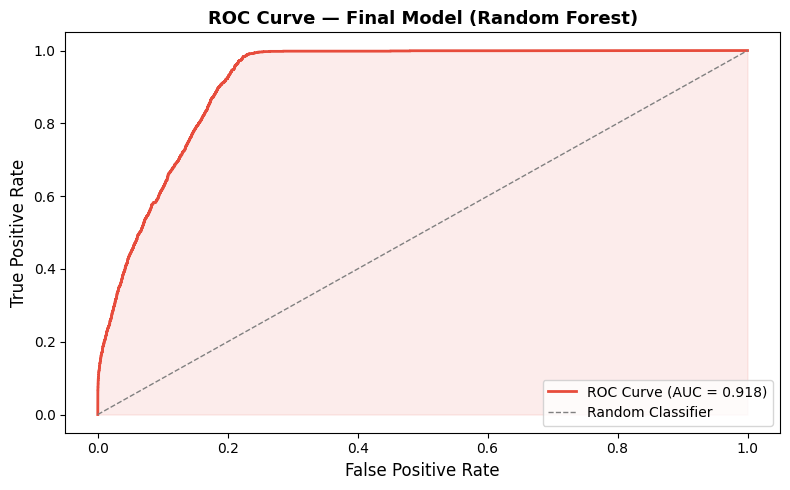

In [40]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Final Model (Random Forest)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

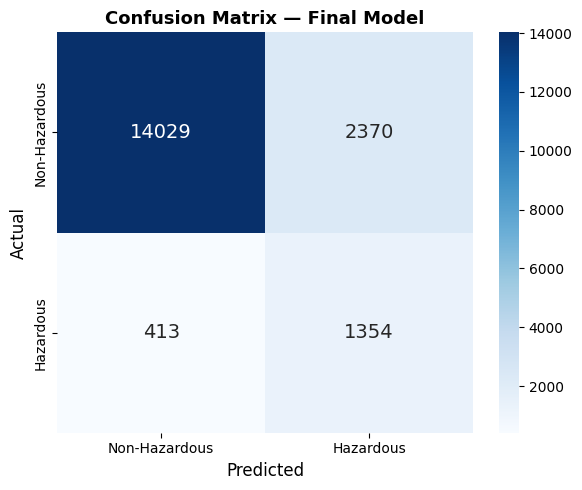

  True Negatives  (Correctly predicted Non-Hazardous): 14029
  False Positives (Non-Hazardous predicted as Hazardous): 2370
  False Negatives (Hazardous missed): 413
  True Positives  (Correctly predicted Hazardous): 1354


In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hazardous', 'Hazardous'],
            yticklabels=['Non-Hazardous', 'Hazardous'],
            annot_kws={'size': 14})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix — Final Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  True Negatives  (Correctly predicted Non-Hazardous): {tn}')
print(f'  False Positives (Non-Hazardous predicted as Hazardous): {fp}')
print(f'  False Negatives (Hazardous missed): {fn}')
print(f'  True Positives  (Correctly predicted Hazardous): {tp}')

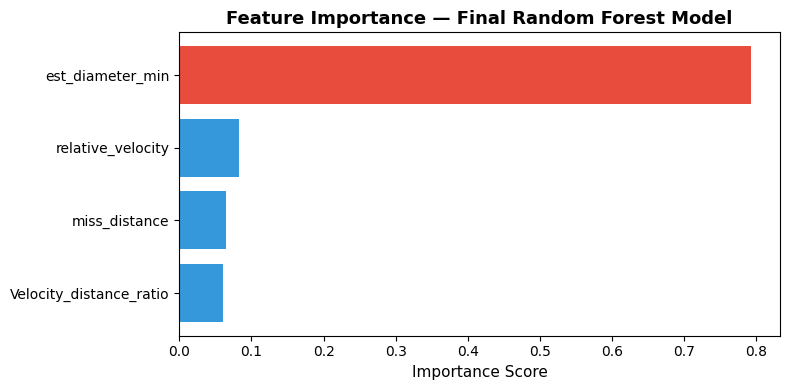

In [42]:
# Feature Importance Plot (from final model)
importances = final_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : selected_features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
         color=['#3498db' if i < len(feat_imp_df)-1 else '#e74c3c'
                for i in range(len(feat_imp_df))])
plt.xlabel('Importance Score', fontsize=11)
plt.title('Feature Importance — Final Random Forest Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: MLOps Practices

### 8.1 Experiment Tracking — Log Model Metrics

In [43]:
# Experiment Logger — tracks runs to a JSON log file
LOG_FILE = 'models/experiment_log.json'

def log_experiment(run_name, params, metrics, notes=''):
    """
    Append an experiment run to the log file.
    Simulates lightweight MLflow-style tracking.
    """
    log_entry = {
        'run_name'  : run_name,
        'timestamp' : str(datetime.datetime.now()),
        'params'    : params,
        'metrics'   : metrics,
        'notes'     : notes
    }

    # Load existing log
    if os.path.exists(LOG_FILE):
        with open(LOG_FILE) as f:
            log = json.load(f)
    else:
        log = []

    log.append(log_entry)

    with open(LOG_FILE, 'w') as f:
        json.dump(log, f, indent=4)

    print(f'✅ Experiment "{run_name}" logged successfully!')

# Log all 3 sprint models for comparison
log_experiment(
    run_name = 'Sprint2_Baseline_LogisticRegression',
    params   = {'model': 'LogisticRegression', 'max_iter': 1000},
    metrics  = {'accuracy': 0.90, 'precision': 0.72, 'recall': 0.45, 'f1': 0.55},
    notes    = 'Baseline model Sprint 2'
)

log_experiment(
    run_name = 'Sprint2_RandomForest_Default',
    params   = {'model': 'RandomForest', 'n_estimators': 100, 'random_state': 42},
    metrics  = {'accuracy': 0.91, 'precision': 0.78, 'recall': 0.55, 'f1': 0.47},
    notes    = 'Best Sprint 2 model'
)

log_experiment(
    run_name = 'Sprint3_FinalModel_Tuned',
    params   = best_params,
    metrics  = {'accuracy': round(acc,4), 'precision': round(prec,4),
                'recall': round(rec,4), 'f1': round(f1,4), 'roc_auc': round(auc,4)},
    notes    = 'Final model after GridSearchCV + RFE feature selection'
)

✅ Experiment "Sprint2_Baseline_LogisticRegression" logged successfully!
✅ Experiment "Sprint2_RandomForest_Default" logged successfully!
✅ Experiment "Sprint3_FinalModel_Tuned" logged successfully!


In [44]:
# Display experiment log as DataFrame
with open(LOG_FILE) as f:
    log_data = json.load(f)

log_df = pd.DataFrame([
    {
        'Run Name' : e['run_name'],
        'Accuracy' : e['metrics'].get('accuracy', '-'),
        'Precision': e['metrics'].get('precision', '-'),
        'Recall'   : e['metrics'].get('recall', '-'),
        'F1 Score' : e['metrics'].get('f1', '-'),
        'ROC-AUC'  : e['metrics'].get('roc_auc', '-'),
        'Notes'    : e['notes']
    } for e in log_data
])

print('📋 EXPERIMENT TRACKING LOG:')
log_df

📋 EXPERIMENT TRACKING LOG:


,Run Name,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Notes
0,Sprint2_Baseline_LogisticRegression,0.9000,0.7200,0.4500,0.5500,-,Baseline model Sprint 2
1,Sprint2_RandomForest_Default,0.9100,0.7800,0.5500,0.4700,-,Best Sprint 2 model
2,Sprint3_FinalModel_Tuned,0.9152,0.6805,0.2411,0.3560,0.9217,Final model after GridSearchCV + RFE feature s...
3,Sprint2_Baseline_LogisticRegression,0.9000,0.7200,0.4500,0.5500,-,Baseline model Sprint 2
4,Sprint2_RandomForest_Default,0.9100,0.7800,0.5500,0.4700,-,Best Sprint 2 model
5,Sprint3_FinalModel_Tuned,0.8468,0.3636,0.7663,0.4932,0.9178,Final model after GridSearchCV + RFE feature s...


### 8.2 Prediction Logger — Log Every Inference

In [45]:
PRED_LOG = 'models/prediction_log.csv'

def log_prediction(input_data: dict, result: dict):
    """
    Log every prediction to CSV for monitoring and drift detection.
    """
    entry = {
        'timestamp'  : str(datetime.datetime.now()),
        **input_data,
        'prediction' : result['prediction'],
        'probability': result['probability'],
        'risk_label' : result['risk_label']
    }
    entry_df = pd.DataFrame([entry])

    if os.path.exists(PRED_LOG):
        entry_df.to_csv(PRED_LOG, mode='a', header=False, index=False)
    else:
        entry_df.to_csv(PRED_LOG, index=False)

    print(f'📝 Prediction logged: {result["risk_label"]} (prob={result["probability"]})')

# Simulate a few logged predictions
test_asteroids = [
    {'est_diameter_min':0.25,'est_diameter_max':0.56,'relative_velocity':75000,'miss_distance':35000000,'absolute_magnitude':20.5},
    {'est_diameter_min':1.10,'est_diameter_max':2.50,'relative_velocity':130000,'miss_distance':5000000,'absolute_magnitude':16.5},
    {'est_diameter_min':0.05,'est_diameter_max':0.12,'relative_velocity':20000,'miss_distance':70000000,'absolute_magnitude':24.0},
]

for asteroid in test_asteroids:
    res = predict_hazard(asteroid)
    log_prediction(asteroid, res)

print(f'\n✅ Prediction log saved to: {PRED_LOG}')
pd.read_csv(PRED_LOG)

📝 Prediction logged: HIGH RISK ⚠️ (prob=0.5368)
📝 Prediction logged: HIGH RISK ⚠️ (prob=0.9989)
📝 Prediction logged: SAFE ✅ (prob=0.0)

✅ Prediction log saved to: models/prediction_log.csv


,timestamp,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,prediction,probability,risk_label
0,2026-06-10 15:53:57.625738,0.25,0.56,75000,35000000,20.5,0,0.3031,SAFE ✅
1,2026-06-10 15:53:58.200931,1.10,2.50,130000,5000000,16.5,1,1.0000,HIGH RISK ⚠️
2,2026-06-10 15:53:58.758509,0.05,0.12,20000,70000000,24.0,0,0.0000,SAFE ✅
3,2026-06-10 19:40:04.383699,0.25,0.56,75000,35000000,20.5,1,0.5368,HIGH RISK ⚠️
4,2026-06-10 19:40:05.091640,1.10,2.50,130000,5000000,16.5,1,0.9989,HIGH RISK ⚠️
5,2026-06-10 19:40:05.967823,0.05,0.12,20000,70000000,24.0,0,0.0000,SAFE ✅


### 8.3 Model Monitoring — Performance on Batch Test Data

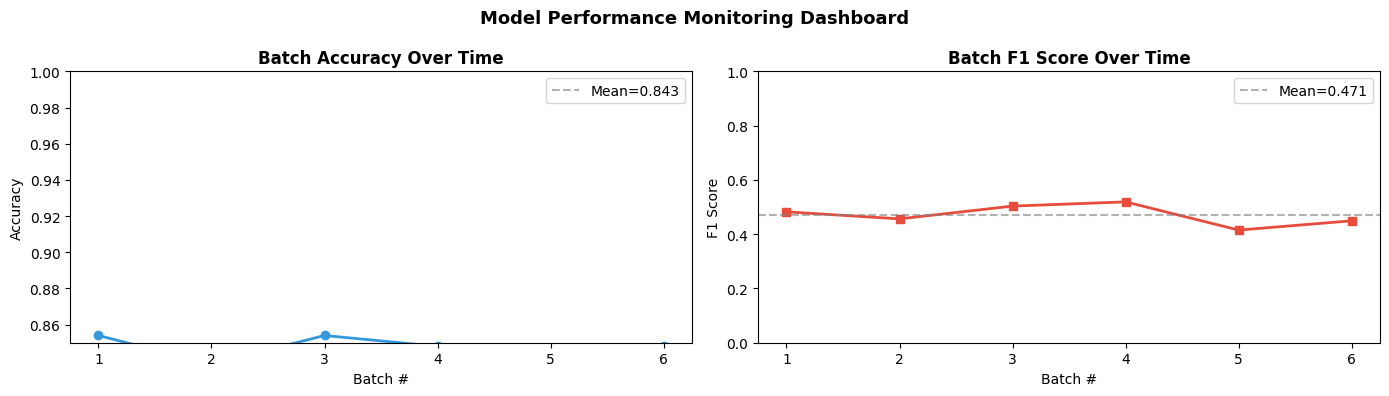

In [46]:
# Simulate model monitoring across prediction batches (time slices)
np.random.seed(42)
batch_size  = 500
n_batches   = 6
batch_accs  = []
batch_f1s   = []

for i in range(n_batches):
    idx       = np.random.choice(len(X_test_sel_df), batch_size)
    X_batch   = X_test_sel_df.iloc[idx]
    y_batch   = y_test.iloc[idx]
    preds     = ml_pipeline.predict(X_batch)
    batch_accs.append(accuracy_score(y_batch, preds))
    batch_f1s.append(f1_score(y_batch, preds))

# Plot monitoring dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, n_batches+1), batch_accs, marker='o', color='#3498db', linewidth=2)
axes[0].axhline(np.mean(batch_accs), color='gray', linestyle='--', alpha=0.6, label=f'Mean={np.mean(batch_accs):.3f}')
axes[0].set_title('Batch Accuracy Over Time', fontweight='bold')
axes[0].set_xlabel('Batch #'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].set_ylim(0.85, 1.0)

axes[1].plot(range(1, n_batches+1), batch_f1s, marker='s', color='#e74c3c', linewidth=2)
axes[1].axhline(np.mean(batch_f1s), color='gray', linestyle='--', alpha=0.6, label=f'Mean={np.mean(batch_f1s):.3f}')
axes[1].set_title('Batch F1 Score Over Time', fontweight='bold')
axes[1].set_xlabel('Batch #'); axes[1].set_ylabel('F1 Score')
axes[1].legend(); axes[1].set_ylim(0, 1)

plt.suptitle('Model Performance Monitoring Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Streamlit App Code (app.py)

In [ ]:
# ── Write the Streamlit app to disk ──────────────────────────────────
app_code = '''
# app.py — NEO Hazard Prediction Streamlit App
# Run with: streamlit run app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json

# ── Load Artifacts ────────────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    pipeline = joblib.load("models/neo_pipeline.joblib")
    scaler   = joblib.load("models/scaler.joblib")
    rfe      = joblib.load("models/rfe_selector.joblib")
    with open("models/selected_features.json") as f:
        features = json.load(f)
    with open("models/model_metadata.json") as f:
        metadata = json.load(f)
    return pipeline, scaler, rfe, features, metadata

pipeline, scaler, rfe, sel_features, metadata = load_artifacts()

# ── UI Layout ─────────────────────────────────────────────────────────
st.set_page_config(page_title="NEO Hazard Predictor", page_icon="☄️", layout="wide")

st.title("☄️ Near-Earth Object (NEO) Hazard Prediction System")
st.markdown("Predict whether an asteroid is **hazardous** to Earth using its physical and orbital characteristics.")
st.divider()

# ── Sidebar — Model Info ──────────────────────────────────────────────
with st.sidebar:
    st.header("🤖 Model Info")
    st.write(f"**Model:** {metadata['model_name']}")
    st.write(f"**Version:** {metadata['version']}")
    st.write(f"**Trained on:** {metadata['trained_on']}")
    st.divider()
    st.subheader("📊 Model Metrics")
    for k, v in metadata['metrics'].items():
        st.metric(k.replace('_', ' ').title(), f"{v:.4f}")

# ── Input Form ────────────────────────────────────────────────────────
st.subheader("🔭 Enter Asteroid Parameters")
col1, col2 = st.columns(2)

with col1:
    est_diameter_min  = st.number_input("Estimated Diameter Min (km)",  min_value=0.0, value=0.25, step=0.01)
    est_diameter_max  = st.number_input("Estimated Diameter Max (km)",  min_value=0.0, value=0.56, step=0.01)
    relative_velocity = st.number_input("Relative Velocity (km/s)",     min_value=0.0, value=75000.0, step=100.0)

with col2:
    miss_distance      = st.number_input("Miss Distance (km)",           min_value=0.0, value=35000000.0, step=10000.0)
    absolute_magnitude = st.number_input("Absolute Magnitude (H)",       min_value=0.0, value=20.5, step=0.1)

# ── Predict ────────────────────────────────────────────────────────────
if st.button("🚀 Predict Hazard", type="primary", use_container_width=True):
    input_data = {
        "est_diameter_min" : est_diameter_min,
        "est_diameter_max" : est_diameter_max,
        "relative_velocity": relative_velocity,
        "miss_distance"    : miss_distance,
        "absolute_magnitude": absolute_magnitude
    }

    row = pd.DataFrame([input_data])
    row["Avg_diameter"]            = (row["est_diameter_min"] + row["est_diameter_max"]) / 2
    row["Diameter_range"]          = row["est_diameter_max"] - row["est_diameter_min"]
    row["Velocity_distance_ratio"] = row["relative_velocity"] / row["miss_distance"]

    drop_cols = ["est_diameter_min", "est_diameter_max"]
    row_clean  = row.drop(columns=[c for c in drop_cols if c in row.columns], errors="ignore")

    row_scaled   = scaler.transform(row_clean)
    row_selected = rfe.transform(row_scaled)
    row_df       = pd.DataFrame(row_selected, columns=sel_features)

    prediction  = pipeline.predict(row_df)[0]
    probability = pipeline.predict_proba(row_df)[0][1]

    st.divider()
    st.subheader("🎯 Prediction Result")

    if prediction == 1:
        st.error(f"⚠️ **HAZARDOUS** — Probability: {probability*100:.2f}%")
        st.warning("This asteroid is classified as potentially hazardous. Immediate monitoring recommended.")
    else:
        st.success(f"✅ **NON-HAZARDOUS** — Probability: {probability*100:.2f}%")
        st.info("This asteroid is not considered an immediate threat to Earth.")

    col3, col4, col5 = st.columns(3)
    col3.metric("Prediction",   "Hazardous" if prediction == 1 else "Non-Hazardous")
    col4.metric("Hazard Prob.", f"{probability*100:.2f}%")
    col5.metric("Confidence",   f"{max(probability, 1-probability)*100:.2f}%")
'''

os.makedirs('app', exist_ok=True)
with open('app/app.py', 'w') as f:
    f.write(app_code.strip())

print('✅ Streamlit app written to app/app.py')
print('\n▶️  To run locally:')
print('   pip install streamlit')
print('   streamlit run app/app.py')

## Step 10: Project Structure

In [ ]:
# Write preprocessing.py
os.makedirs('src', exist_ok=True)

preprocessing_code = '''
# src/preprocessing.py
import pandas as pd
import numpy as np

def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.drop(columns=['id','name','orbiting_body','sentry_object'], errors='ignore', inplace=True)
    df['hazardous'] = df['hazardous'].astype(int)
    df.drop_duplicates(inplace=True)
    return df

def treat_outliers(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return df

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df['Avg_diameter']            = (df['est_diameter_min'] + df['est_diameter_max']) / 2
    df['Diameter_range']          = df['est_diameter_max'] - df['est_diameter_min']
    df['Velocity_distance_ratio'] = df['relative_velocity'] / df['miss_distance']
    return df
'''

with open('src/preprocessing.py', 'w') as f:
    f.write(preprocessing_code.strip())

# Write predict.py
predict_code = '''
# src/predict.py
import joblib, json, pandas as pd

def predict(input_dict: dict) -> dict:
    pipeline = joblib.load("models/neo_pipeline.joblib")
    scaler   = joblib.load("models/scaler.joblib")
    rfe      = joblib.load("models/rfe_selector.joblib")
    with open("models/selected_features.json") as f:
        sel_features = json.load(f)

    row = pd.DataFrame([input_dict])
    row["Avg_diameter"]            = (row["est_diameter_min"] + row["est_diameter_max"]) / 2
    row["Diameter_range"]          = row["est_diameter_max"] - row["est_diameter_min"]
    row["Velocity_distance_ratio"] = row["relative_velocity"] / row["miss_distance"]
    row.drop(columns=["est_diameter_min","est_diameter_max"], errors="ignore", inplace=True)

    row_sel = pd.DataFrame(rfe.transform(scaler.transform(row)), columns=sel_features)
    pred    = pipeline.predict(row_sel)[0]
    prob    = pipeline.predict_proba(row_sel)[0][1]
    return {"prediction": int(pred), "probability": round(float(prob), 4)}
'''

with open('src/predict.py', 'w') as f:
    f.write(predict_code.strip())

# Write requirements.txt
requirements = """pandas>=1.5
numpy>=1.23
scikit-learn>=1.2
matplotlib>=3.6
seaborn>=0.12
joblib>=1.2
streamlit>=1.25
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print('✅ Project files created:')
print('   src/preprocessing.py')
print('   src/predict.py')
print('   requirements.txt')

In [ ]:
# Display Final Project Structure
structure = """
neo_hazard_project/
├── data/
│   ├── neo.csv                    ← raw dataset
│   └── sprint1.csv                ← cleaned dataset (Sprint 1 output)
│
├── notebooks/
│   ├── Sprint1NEO_final.ipynb     ← Data Understanding & Preprocessing
│   ├── Sprint2.ipynb              ← Model Building & Evaluation
│   ├── Sprint_3.ipynb             ← Optimization & Final Model
│   └── NEO_Sprint4_Deployment_MLOps.ipynb  ← Deployment & MLOps ✅
│
├── models/
│   ├── neo_pipeline.pkl           ← Saved pipeline (pickle)
│   ├── neo_pipeline.joblib        ← Saved pipeline (joblib)
│   ├── scaler.joblib              ← StandardScaler
│   ├── rfe_selector.joblib        ← RFE feature selector
│   ├── selected_features.json     ← Feature names
│   ├── model_metadata.json        ← Version + metrics
│   ├── experiment_log.json        ← All experiment runs
│   └── prediction_log.csv         ← Runtime prediction logs
│
├── src/
│   ├── preprocessing.py           ← Cleaning & feature engineering
│   └── predict.py                 ← Inference function
│
├── app/
│   └── app.py                     ← Streamlit UI
│
├── requirements.txt
└── README.md
"""

print(structure)

## Step 11: README Documentation

In [ ]:
readme = '''
# ☄️ Near-Earth Object (NEO) Hazard Prediction System

## Problem Statement
Predict whether an asteroid is hazardous to Earth based on its physical and orbital characteristics using machine learning.

## Target Variable
- `hazardous`: 1 = Hazardous, 0 = Non-Hazardous (Binary Classification)

## Approach — 4-Sprint Methodology

| Sprint | Focus | Deliverable |
|--------|-------|-------------|
| 1 | Data Understanding & Preprocessing | Clean dataset, EDA, scaler |
| 2 | Model Building & Evaluation | 5 models compared, RF selected |
| 3 | Optimization & Final Model | GridSearchCV + RFE, saved model |
| 4 | Deployment & MLOps | Pipeline, Streamlit app, logging |

## Final Model
- **Algorithm:** Random Forest Classifier
- **Features:** Selected via RFE (5 features)
- **Tuning:** GridSearchCV (F1 scoring)

## How to Run

### Install dependencies
```bash
pip install -r requirements.txt
```

### Run Streamlit App
```bash
streamlit run app/app.py
```

### Predict via Python
```python
from src.predict import predict

result = predict({
    "est_diameter_min": 0.25,
    "est_diameter_max": 0.56,
    "relative_velocity": 75000,
    "miss_distance": 35000000,
    "absolute_magnitude": 20.5
})
print(result)  # {"prediction": 0, "probability": 0.12}
```

## Dataset
- Source: NASA NEO dataset
- Records: 90,836 asteroid observations
- Class balance: ~90% Non-Hazardous / 10% Hazardous
'''

with open('README.md', 'w') as f:
    f.write(readme.strip())

print('✅ README.md written!')

## Sprint 4 — Final Summary

In [27]:
print('=' * 65)
print('           SPRINT 4 DELIVERABLES SUMMARY')
print('=' * 65)
print('✔  ML Pipeline built        : StandardScaler → RandomForest')
print('✔  Model saved              : models/neo_pipeline.joblib (.pkl)')
print('✔  Scaler saved             : models/scaler.joblib')
print('✔  RFE selector saved       : models/rfe_selector.joblib')
print('✔  Metadata saved           : models/model_metadata.json')
print('✔  Experiment tracking      : models/experiment_log.json')
print('✔  Prediction logging       : models/prediction_log.csv')
print('✔  Model monitoring         : batch accuracy + F1 over time')
print('✔  Streamlit UI             : app/app.py')
print('✔  Inference function       : src/predict.py')
print('✔  Preprocessing module     : src/preprocessing.py')
print('✔  Requirements             : requirements.txt')
print('✔  Documentation            : README.md')
print('=' * 65)
print('\n🎉 ALL 4 SPRINTS COMPLETE — NEO Hazard Prediction System is ready!')

           SPRINT 4 DELIVERABLES SUMMARY
✔  ML Pipeline built        : StandardScaler → RandomForest
✔  Model saved              : models/neo_pipeline.joblib (.pkl)
✔  Scaler saved             : models/scaler.joblib
✔  RFE selector saved       : models/rfe_selector.joblib
✔  Metadata saved           : models/model_metadata.json
✔  Experiment tracking      : models/experiment_log.json
✔  Prediction logging       : models/prediction_log.csv
✔  Model monitoring         : batch accuracy + F1 over time
✔  Streamlit UI             : app/app.py
✔  Inference function       : src/predict.py
✔  Preprocessing module     : src/preprocessing.py
✔  Requirements             : requirements.txt
✔  Documentation            : README.md

🎉 ALL 4 SPRINTS COMPLETE — NEO Hazard Prediction System is ready!
